# Anomaly Detection of Melanoma in Dermoscopic Images
### 50.039 Deep Learning Y2026
#### Group 16

| Student Name           | Student Number |
|------------------------|----------------|
| Gay Jun Han Dylan      | 1007831        |
| Lydia Rachel Robert    | 1008462        |
| Yeo Chun Sheng Joel    | 1008112        |

## Overview

This notebook reproduces the best model presented in our report, which achieved the **highest AUC score of 0.9235**. It loads two pre-trained model checkpoints directly from `models/` — **no retraining required**:

| Checkpoint | Architecture | Val AUC | Test F2 |
|---|---|---|---|
| `models/efficientnet_b0_l1_metadata_best.pth` | EfficientNet-B0 + metadata | 0.9167 | 0.6952 |
| `models/01.mobilenet_v3_metadata_best.pth` | MobileNetV3-Large + metadata | 0.9188 | 0.6492 |

The two models are ensembled by **averaging their 8× TTA probabilities**, then thresholded at the value that maximises F2 on the validation set.

## Setup — Imports & Device

Import required libraries, fix the random seed for reproducibility, and select the compute device (CUDA, MPS, or CPU).

In [1]:
import sys
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torchvision import transforms
from sklearn.metrics import fbeta_score
import pandas as pd

ROOT = next(p for p in [Path.cwd()] + list(Path.cwd().parents) if (p / 'src').exists())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.data.dataset import HAM10000DatasetWithMetadata
from src.models.efficientnet import EfficientNetB0WithMetadata
from src.models.mobilenet import MobileNetV3LargeWithMetadata
from src.utils import seed_everything

g = seed_everything(42)

if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

Using device: cuda


## Data — Load Validation and Test Sets

Define paths to both model checkpoints and the patient metadata files, then construct the validation and test datasets using the metadata-aware dataset class.

In [2]:
METADATA_PATH      = str(ROOT / 'data_new/raw/HAM10000_metadata')
TEST_METADATA_PATH = str(ROOT / 'data_new/raw/ISIC2018_Task3_Test_GroundTruth.csv')
METADATA_DIM = 17

EFFICIENTNET_CKPT = ROOT / 'models/efficientnet_b0_l1_metadata_best.pth'
MOBILENET_CKPT    = ROOT / 'models/01.mobilenet_v3_metadata_best.pth'

val_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/val.csv'),
    image_dir=str(ROOT / 'data_new/images/train'),
    metadata_path=METADATA_PATH,
    transform=None,
)

test_dataset = HAM10000DatasetWithMetadata(
    csv_path=str(ROOT / 'data_new/splits/test.csv'),
    image_dir=str(ROOT / 'data_new/images/test'),
    metadata_path=TEST_METADATA_PATH,
    transform=None,
)

print(f'Val: {len(val_dataset)} | Test: {len(test_dataset)}')

Val: 2024 | Test: 1511


## Model — Load Checkpoints

Instantiate EfficientNet-B0 and MobileNetV3-Large with their metadata fusion heads, load the saved weights directly from disk, and set both models to evaluation mode. No training is performed.

In [3]:
efficientnet = EfficientNetB0WithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=True,
    dropout=0.5,
).to(device)
efficientnet.load_state_dict(torch.load(str(EFFICIENTNET_CKPT), map_location=device))
efficientnet.eval()
print('EfficientNet-B0 loaded.')

mobilenet = MobileNetV3LargeWithMetadata(
    metadata_dim=METADATA_DIM,
    num_classes=1,
    freeze_backbone=False,
    dropout=0.5,
).to(device)
mobilenet.load_state_dict(torch.load(str(MOBILENET_CKPT), map_location=device))
mobilenet.eval()
print('MobileNetV3-Large loaded.')

EfficientNet-B0 loaded.
MobileNetV3-Large loaded.


## Inference — TTA Transforms & Prediction Helper

Define eight test-time augmentation transforms (identity, flips, and rotations) and the `tta_predict_single` helper that runs all augmentations through a single model and averages the resulting probabilities.

In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def _base(extra=None):
    ops = [transforms.Resize((224, 224))]
    if extra:
        ops += extra
    ops += [transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)]
    return transforms.Compose(ops)

tta_transforms = [
    _base(),
    _base([transforms.RandomHorizontalFlip(p=1.0)]),
    _base([transforms.RandomVerticalFlip(p=1.0)]),
    _base([transforms.RandomHorizontalFlip(p=1.0), transforms.RandomVerticalFlip(p=1.0)]),
    _base([transforms.RandomRotation(degrees=(90, 90))]),
    _base([transforms.RandomRotation(degrees=(180, 180))]),
    _base([transforms.RandomRotation(degrees=(270, 270))]),
    _base([transforms.RandomRotation(degrees=(45, 45))]),
]


def tta_predict_single(model, dataset, device, tta_transforms):
    all_probs, all_labels = [], []
    with torch.no_grad():
        for idx in range(len(dataset)):
            pil_img, metadata, label = dataset[idx]
            metadata = metadata.unsqueeze(0).to(device)
            preds = [
                torch.sigmoid(model(t(pil_img).unsqueeze(0).to(device), metadata)).item()
                for t in tta_transforms
            ]
            all_probs.append(np.mean(preds))
            all_labels.append(label)
    return np.array(all_probs), np.array(all_labels)

## Threshold Tuning — Validation Set

Run 8× TTA through both models on the validation set and average their probabilities to form the ensemble prediction. Sweep thresholds from 0.01 to 0.90 to find the value that maximises the F2 score.

In [5]:
print('Running TTA on validation set (EfficientNet-B0)...')
val_probs_eff, val_labels = tta_predict_single(efficientnet, val_dataset, device, tta_transforms)

print('Running TTA on validation set (MobileNetV3-Large)...')
val_probs_mob, _ = tta_predict_single(mobilenet, val_dataset, device, tta_transforms)

val_probs_ensemble = (val_probs_eff + val_probs_mob) / 2.0

thresholds = np.arange(0.01, 0.90, 0.01)
f2_scores = [
    fbeta_score(val_labels, (val_probs_ensemble >= t).astype(int), beta=2, pos_label=1, zero_division=0)
    for t in thresholds
]
best_threshold = thresholds[np.argmax(f2_scores)]
print(f'Best threshold: {best_threshold:.2f} | Val F2: {max(f2_scores):.4f}')

Running TTA on validation set (EfficientNet-B0)...
Running TTA on validation set (MobileNetV3-Large)...
Best threshold: 0.50 | Val F2: 0.7023


## Evaluation — Test Set

Run the same ensemble TTA pipeline on the held-out test set using the tuned threshold, then report AUC-ROC, balanced accuracy, F2, the full per-class classification report, confusion matrix, and ROC curve.

Running TTA on test set (EfficientNet-B0)...
Running TTA on test set (MobileNetV3-Large)...
Threshold:          0.50
AUC-ROC:            0.9235
Balanced Accuracy:  0.8371
F2 Score:           0.6781

              precision    recall  f1-score   support

Non-Melanoma     0.9807    0.7970    0.8794      1340
    Melanoma     0.3555    0.8772    0.5059       171

    accuracy                         0.8061      1511
   macro avg     0.6681    0.8371    0.6926      1511
weighted avg     0.9100    0.8061    0.8371      1511



c:\Users\Dylan Gay\Documents\SUTD\Deep Learning\50.039-Deep-Learning\dl_venv\Lib\site-packages\sklearn\utils\_plotting.py:385: FutureWarning: `estimator_name` is deprecated in 1.7 and will be removed in 1.9. Use `name` instead.
  warnings.warn(


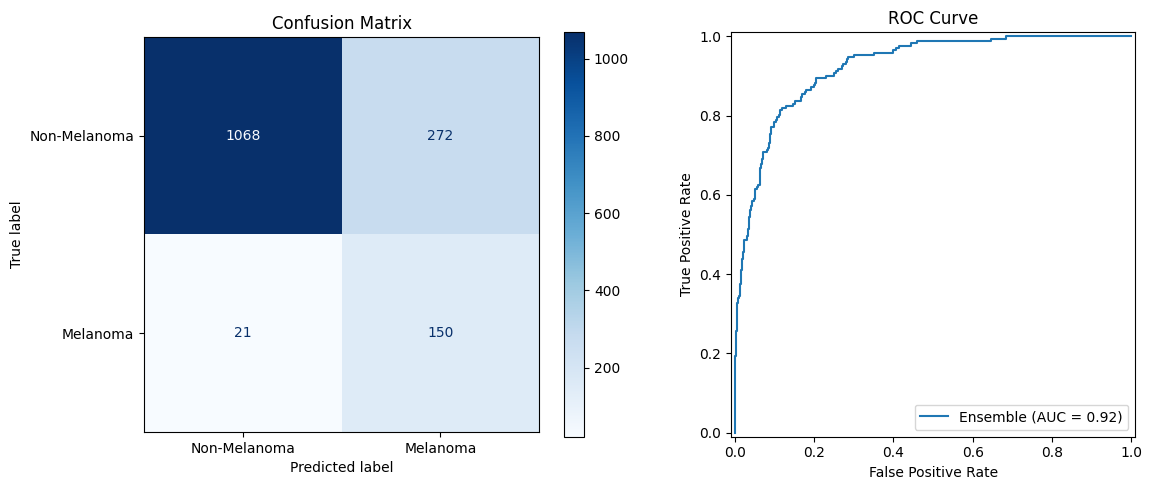

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, balanced_accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_curve, RocCurveDisplay,
)

CLASS_NAMES = ['Non-Melanoma', 'Melanoma']

print('Running TTA on test set (EfficientNet-B0)...')
test_probs_eff, test_labels = tta_predict_single(efficientnet, test_dataset, device, tta_transforms)

print('Running TTA on test set (MobileNetV3-Large)...')
test_probs_mob, _ = tta_predict_single(mobilenet, test_dataset, device, tta_transforms)

test_probs_ensemble = (test_probs_eff + test_probs_mob) / 2.0
all_preds = (test_probs_ensemble >= best_threshold).astype(int)

auc     = roc_auc_score(test_labels, test_probs_ensemble)
bal_acc = balanced_accuracy_score(test_labels, all_preds)
f2      = fbeta_score(test_labels, all_preds, beta=2, pos_label=1, zero_division=0)

print(f'Threshold:          {best_threshold:.2f}')
print(f'AUC-ROC:            {auc:.4f}')
print(f'Balanced Accuracy:  {bal_acc:.4f}')
print(f'F2 Score:           {f2:.4f}')
print()
print(classification_report(test_labels, all_preds, target_names=CLASS_NAMES, digits=4))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm = confusion_matrix(test_labels, all_preds)
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES).plot(cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix')

fpr, tpr, _ = roc_curve(test_labels, test_probs_ensemble)
RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=auc, estimator_name='Ensemble').plot(ax=axes[1])
axes[1].set_title('ROC Curve')

fig.tight_layout()
plt.show()

## Comparison — ROC Curves: Ensemble vs EfficientNet-B0 vs MobileNetV3-Large

Overlay the ROC curves for all three models on a single plot to visualise how much the ensemble improves over each individual model.

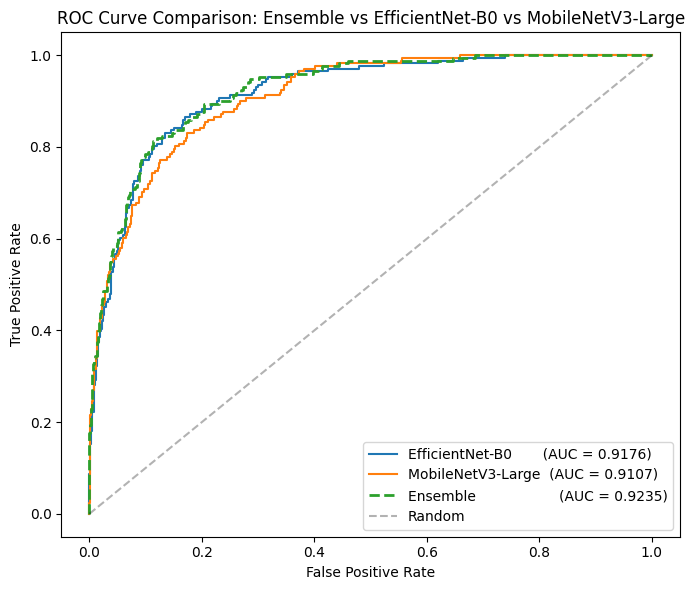

In [14]:
auc_eff = roc_auc_score(test_labels, test_probs_eff)
auc_mob = roc_auc_score(test_labels, test_probs_mob)
# auc (ensemble) already computed above

fpr_eff, tpr_eff, _ = roc_curve(test_labels, test_probs_eff)
fpr_mob, tpr_mob, _ = roc_curve(test_labels, test_probs_mob)
fpr_ens, tpr_ens, _ = roc_curve(test_labels, test_probs_ensemble)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_eff, tpr_eff, label=f'EfficientNet-B0       (AUC = {auc_eff:.4f})')
ax.plot(fpr_mob, tpr_mob, label=f'MobileNetV3-Large  (AUC = {auc_mob:.4f})')
ax.plot(fpr_ens, tpr_ens, label=f'Ensemble                   (AUC = {auc:.4f})', linestyle='--', linewidth=2)
ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, label='Random')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve Comparison: Ensemble vs EfficientNet-B0 vs MobileNetV3-Large')
ax.legend(loc='lower right')
fig.tight_layout()
plt.show()